<a href="https://colab.research.google.com/github/esinghbe23-ctrl/Deep-Learning-Assignments/blob/main/ASS_2(DL_without_inbuilt_func_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

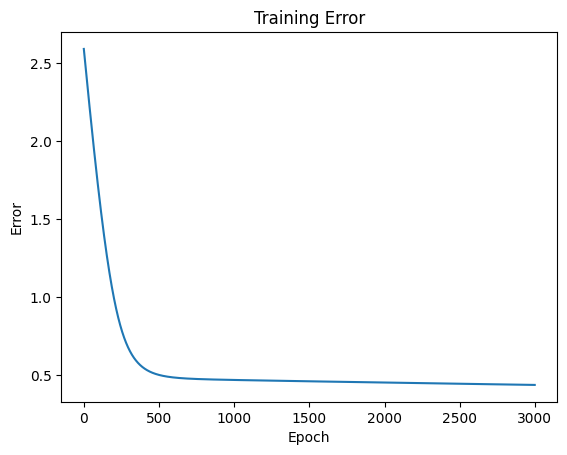

Minimum error achieved: 0.43730789763467764
Weights: [ 0.52198909 -0.72237973]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Assume iris dataset is already available
X = iris.data[:, :2]
y = (iris.target != 0) * 1


class LogisticRegressionSinglePerceptronModel:

    def __init__(self, eta, inputLayer, outputLayer):
        self.eta = eta
        self.inputLayer = inputLayer
        self.outputLayer = outputLayer
        self.w = np.random.randn(inputLayer)
        self.E = []
        self.w_list = []

    def sigmoid(self, x):
        return 1/(1+np.exp(-x))

    def feedforward(self, X):
        z = np.dot(X, self.w)
        h = self.sigmoid(z)
        return h

    def error(self, h, y):
        error = (-y*np.log(h) - (1-y)*np.log(1-h)).mean()
        self.E.append(error)

    def backprop(self, X, y, h):
        delta_E_w = np.dot(X.T, (h - y)) / len(y)
        self.w_list.append(self.w.copy())
        self.w = self.w - self.eta * delta_E_w

    def predict(self, X):
        return self.feedforward(X)

    def classify(self, X):
        return self.predict(X).round()

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            h = self.feedforward(X)
            self.backprop(X, y, h)
            self.error(h, y)

    def plot(self):
        plt.plot(self.E)
        plt.xlabel("Epoch")
        plt.ylabel("Error")
        plt.title("Training Error")
        plt.show()


eta = 0.0005
epochs = 3000
inputLayer = X.shape[1]
outputLayer = 1

SPNN = LogisticRegressionSinglePerceptronModel(eta, inputLayer, outputLayer)

SPNN.train(X, y, epochs)

SPNN.plot()

pred = SPNN.predict(X)
pred2 = SPNN.classify(X)

print("Minimum error achieved:", min(SPNN.E))
print("Weights:", SPNN.w)